# Parte 2: Regresión Logística - Predicción de aprobación de estudiantes

Este notebook desarrolla un ejercicio práctico guiado de **Machine Learning supervisado** usando **Regresión Logística**.

El objetivo es predecir si un estudiante aprobará un examen a partir de una variable muy sencilla: la cantidad de **horas de estudio**.

La salida del modelo será binaria:

- `0`: no aprobó.
- `1`: aprobó.


## 1. Explicación breve del problema

Queremos resolver un problema de **clasificación binaria**. Esto significa que el modelo debe elegir entre dos clases posibles: aprobar o no aprobar.

Aunque el ejemplo es simple, representa una idea muy importante: la regresión logística no predice directamente una nota, sino una **probabilidad de pertenecer a una clase**. En este caso, calcula la probabilidad de que un estudiante apruebe según las horas estudiadas.

Después convertimos esa probabilidad en una clase usando un umbral. Normalmente se usa `0.5`:

- Si la probabilidad es mayor o igual a `0.5`, predecimos `aprobado = 1`.
- Si la probabilidad es menor que `0.5`, predecimos `aprobado = 0`.


## 2. Importación de librerías

Usaremos librerías habituales en ciencia de datos:

- `numpy` para cálculos numéricos.
- `pandas` para trabajar con tablas.
- `matplotlib` para visualizar los datos.
- `scikit-learn` para dividir los datos, entrenar el modelo y evaluar resultados.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)

# Configuración visual sencilla para que los gráficos sean más claros.
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print('Librerías importadas correctamente.')


Librerías importadas correctamente.


## 3. Creación del dataset

En el repositorio no había un dataset previo, así que crearemos uno sintético dentro del notebook.

Para que el ejercicio sea reproducible usamos una semilla aleatoria (`seed=42`). Esto permite que, si otra persona ejecuta el notebook, obtenga los mismos datos y resultados.

El dataset tendrá dos columnas:

- `horas_estudio`: cantidad de horas estudiadas.
- `aprobado`: resultado del examen, donde `0` significa no aprobado y `1` significa aprobado.

La idea general será que, a más horas de estudio, mayor probabilidad de aprobar. Pero añadiremos algo de variabilidad para que el ejemplo se parezca un poco más a una situación real.


In [2]:
# Generamos datos reproducibles.
rng = np.random.default_rng(seed=42)

# Creamos 40 valores de horas de estudio entre 0.5 y 10 horas, con un poco de ruido.
horas_estudio = np.round(np.linspace(0.5, 10, 40) + rng.normal(0, 0.35, 40), 1)
horas_estudio = np.clip(horas_estudio, 0.5, 10)

# Convertimos las horas en una probabilidad usando una función sigmoide.
# La probabilidad aumenta alrededor de las 5 horas de estudio.
probabilidad_real = 1 / (1 + np.exp(-1.25 * (horas_estudio - 5)))

# Generamos la variable objetivo con cierta variabilidad.
aprobado = rng.binomial(n=1, p=probabilidad_real)

# Construimos el DataFrame final.
datos = pd.DataFrame({
    'horas_estudio': horas_estudio,
    'aprobado': aprobado,
})

print('Primeras filas del dataset:')
print(datos.head(10).to_string(index=False))


Primeras filas del dataset:
 horas_estudio  aprobado
           0.6         0
           0.5         0
           1.2         0
           1.6         0
           0.8         0
           1.3         0
           2.0         0
           2.1         0
           2.4         0
           2.4         0


## 4. Exploración inicial de los datos

Antes de entrenar un modelo, conviene revisar qué contiene el dataset: tamaño, tipos de variables, valores resumen y distribución de la clase objetivo.


In [3]:
print('Dimensiones del dataset:', datos.shape)
print('\nTipos de datos:')
print(datos.dtypes)

print('\nResumen estadístico:')
print(datos.describe().to_string())

print('\nCantidad de estudiantes por clase:')
print(datos['aprobado'].value_counts().rename(index={0: 'No aprobado', 1: 'Aprobado'}).to_string())


Dimensiones del dataset: (40, 2)

Tipos de datos:
horas_estudio    float64
aprobado           int64
dtype: object

Resumen estadístico:
       horas_estudio   aprobado
count      40.000000  40.000000
mean        5.262500   0.525000
std         2.880321   0.505736
min         0.500000   0.000000
25%         3.000000   0.000000
50%         5.250000   1.000000
75%         7.750000   1.000000
max        10.000000   1.000000

Cantidad de estudiantes por clase:
aprobado
Aprobado       21
No aprobado    19


### Interpretación rápida de la exploración

El dataset tiene **40 estudiantes** y dos columnas: `horas_estudio` y `aprobado`. Es un dataset pequeño y creado para practicar, por eso no debe interpretarse como una muestra real.

La clase objetivo está bastante equilibrada: hay **21 estudiantes aprobados** y **19 no aprobados**. Esto es positivo para el ejercicio, porque evita que el modelo aprenda solamente la clase mayoritaria.

También vemos que las horas de estudio van aproximadamente desde **0.5 hasta 10 horas**. Esta variable será la única información que usará el modelo, así que el resultado dependerá completamente de la relación entre estudiar más horas y aprobar.

## 5. Visualización simple de la relación entre horas y aprobación

El siguiente gráfico muestra cada estudiante como un punto. En el eje X vemos las horas de estudio y en el eje Y el resultado real del examen.

Como `aprobado` solo puede valer `0` o `1`, los puntos aparecen en dos niveles:

- Abajo: estudiantes que no aprobaron.
- Arriba: estudiantes que aprobaron.


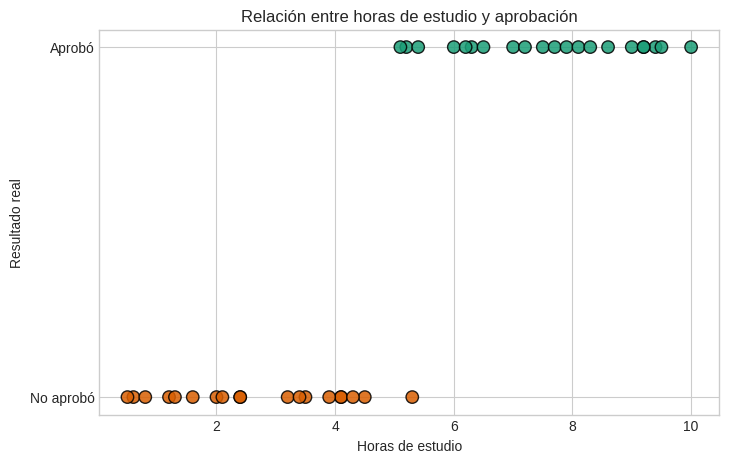

In [4]:
colores = datos['aprobado'].map({0: '#d95f02', 1: '#1b9e77'})

plt.scatter(datos['horas_estudio'], datos['aprobado'], c=colores, s=80, edgecolor='black', alpha=0.85)
plt.yticks([0, 1], ['No aprobó', 'Aprobó'])
plt.xlabel('Horas de estudio')
plt.ylabel('Resultado real')
plt.title('Relación entre horas de estudio y aprobación')
plt.show()


### Interpretación del gráfico de dispersión

El gráfico muestra una tendencia clara: cuando las horas de estudio son bajas, la mayoría de los estudiantes aparece en la clase **No aprobó**. Cuando las horas aumentan, empiezan a aparecer más casos en la clase **Aprobó**.

La zona más interesante está alrededor de las **4 a 6 horas**, porque ahí los puntos están más cerca del cambio entre no aprobar y aprobar. Esa zona es importante porque probablemente el modelo ubicará allí su frontera de decisión.

Este gráfico también muestra que el problema no es una predicción numérica de nota, sino una clasificación: cada estudiante termina en una de dos clases posibles.

## 6. Separación de variables: X e Y

En Machine Learning se suele separar el dataset en:

- `X`: variables de entrada o características. Aquí será `horas_estudio`.
- `y`: variable objetivo o etiqueta. Aquí será `aprobado`.

Scikit-learn espera que `X` tenga formato de tabla, aunque solo tenga una columna. Por eso usamos doble corchete: `datos[['horas_estudio']]`.


In [5]:
X = datos[['horas_estudio']]
y = datos['aprobado']

print('Primeras filas de X:')
print(X.head().to_string(index=False))

print('\nPrimeros valores de y:')
print(y.head().to_string(index=False))

print('\nForma de X:', X.shape)
print('Forma de y:', y.shape)


Primeras filas de X:
 horas_estudio
           0.6
           0.5
           1.2
           1.6
           0.8

Primeros valores de y:
0
0
0
0
0

Forma de X: (40, 1)
Forma de y: (40,)


## 7. División en entrenamiento y prueba

Dividimos los datos en dos partes:

- **Entrenamiento**: datos que el modelo usa para aprender.
- **Prueba**: datos que el modelo no vio durante el entrenamiento y que usamos para evaluar si generaliza bien.

Usamos `stratify=y` para mantener una proporción similar de aprobados y no aprobados en ambos conjuntos.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print('Tamaño del conjunto de entrenamiento:', X_train.shape[0], 'filas')
print('Tamaño del conjunto de prueba:', X_test.shape[0], 'filas')

print('\nDistribución en entrenamiento:')
print(y_train.value_counts().sort_index().rename(index={0: 'No aprobado', 1: 'Aprobado'}).to_string())

print('\nDistribución en prueba:')
print(y_test.value_counts().sort_index().rename(index={0: 'No aprobado', 1: 'Aprobado'}).to_string())


Tamaño del conjunto de entrenamiento: 30 filas
Tamaño del conjunto de prueba: 10 filas

Distribución en entrenamiento:
aprobado
No aprobado    14
Aprobado       16

Distribución en prueba:
aprobado
No aprobado    5
Aprobado       5


### Interpretación de la división train/test

El conjunto de entrenamiento tiene **30 estudiantes** y el conjunto de prueba tiene **10 estudiantes**. El modelo aprende con los 30 casos de entrenamiento y luego se evalúa con los 10 casos que no vio antes.

Usamos `stratify=y`, por eso el conjunto de prueba queda equilibrado: **5 estudiantes no aprobados** y **5 aprobados**. Esto hace que la evaluación sea más justa, porque el modelo se prueba con ambas clases.

## 8. Entrenamiento del modelo de Regresión Logística

Ahora creamos y entrenamos el modelo con `LogisticRegression`.

La regresión logística aprende una curva sigmoide. Esa curva transforma las horas de estudio en una probabilidad entre 0 y 1.


In [7]:
modelo = LogisticRegression(random_state=42)
modelo.fit(X_train, y_train)

print('Modelo entrenado correctamente.')
print(f'Intercepto (beta0): {modelo.intercept_[0]:.4f}')
print(f'Coeficiente para horas_estudio (beta1): {modelo.coef_[0][0]:.4f}')

if modelo.coef_[0][0] > 0:
    print('Interpretación: al aumentar las horas de estudio, aumenta la probabilidad estimada de aprobar.')
else:
    print('Interpretación: al aumentar las horas de estudio, disminuye la probabilidad estimada de aprobar.')


Modelo entrenado correctamente.
Intercepto (beta0): -8.9134
Coeficiente para horas_estudio (beta1): 1.7010
Interpretación: al aumentar las horas de estudio, aumenta la probabilidad estimada de aprobar.


### Interpretación del entrenamiento

El coeficiente de `horas_estudio` es positivo. Esto significa que, según el modelo, **a más horas de estudio, mayor probabilidad de aprobar**.

El intercepto y el coeficiente son los valores que el modelo aprendió durante el entrenamiento. Con ellos construye la curva logística que convierte las horas estudiadas en una probabilidad entre 0 y 1.

En este ejercicio, el resultado tiene sentido porque el dataset fue creado con una relación positiva entre estudiar más y aprobar.

## 9. Predicciones sobre el conjunto de prueba

Con el modelo ya entrenado, hacemos predicciones sobre los datos de prueba.

Obtendremos dos cosas:

- `y_pred`: clase predicha, `0` o `1`.
- `y_proba`: probabilidad estimada de aprobar.


In [8]:
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

resultados_prueba = X_test.copy()
resultados_prueba['aprobado_real'] = y_test.values
resultados_prueba['probabilidad_aprobar'] = y_proba
resultados_prueba['prediccion'] = y_pred
resultados_prueba = resultados_prueba.sort_values('horas_estudio')

print(resultados_prueba.to_string(index=False, formatters={'probabilidad_aprobar': '{:.3f}'.format}))


 horas_estudio  aprobado_real probabilidad_aprobar  prediccion
           2.0              0                0.004           0
           2.1              0                0.005           0
           3.2              0                0.030           0
           3.4              0                0.042           0
           4.1              0                0.126           0
           5.1              1                0.441           0
           5.2              1                0.483           0
           8.6              1                0.997           1
           9.2              1                0.999           1
           9.4              1                0.999           1


### Interpretación de las predicciones

En la tabla de prueba se observa que el modelo clasifica correctamente a los estudiantes con pocas horas de estudio como **no aprobados** y a los estudiantes con muchas horas como **aprobados**.

Los errores aparecen en estudiantes con **5.1 y 5.2 horas de estudio**. Aunque realmente aprobaron, el modelo les asignó una probabilidad menor a 0.5 y los clasificó como no aprobados.

Esto es importante: el modelo no “sabe” con certeza quién aprueba. Calcula una probabilidad y luego aplica un umbral. Los casos cercanos al umbral son los más difíciles de clasificar.

## 10. Evaluación del modelo

Para evaluar un modelo de clasificación no alcanza con mirar una sola métrica. Revisaremos:

- **Accuracy**: porcentaje total de aciertos.
- **Matriz de confusión**: tipos de aciertos y errores.
- **Precision**: de todo lo predicho como aprobado, cuánto realmente aprobó.
- **Recall**: de todos los aprobados reales, cuántos encontró el modelo.
- **F1-score**: equilibrio entre precision y recall.
- **Classification report**: resumen de métricas por clase.
- **ROC-AUC**: capacidad del modelo para separar aprobados de no aprobados usando probabilidades.


In [9]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
matriz = confusion_matrix(y_test, y_pred)

print(f'Accuracy:  {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall:    {recall:.3f}')
print(f'F1-score:  {f1:.3f}')
print(f'ROC-AUC:   {roc_auc:.3f}')

print('\nMatriz de confusión:')
print(matriz)

print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['No aprobado', 'Aprobado']))


Accuracy:  0.800
Precision: 1.000
Recall:    0.600
F1-score:  0.750
ROC-AUC:   1.000

Matriz de confusión:
[[5 0]
 [2 3]]

Classification report:
              precision    recall  f1-score   support

 No aprobado       0.71      1.00      0.83         5
    Aprobado       1.00      0.60      0.75         5

    accuracy                           0.80        10
   macro avg       0.86      0.80      0.79        10
weighted avg       0.86      0.80      0.79        10



### Interpretación de las métricas obtenidas

El modelo obtuvo una **accuracy de 0.80**, es decir, acertó 8 de cada 10 casos del conjunto de prueba.

La **precision es 1.00**. Esto significa que, cada vez que el modelo predijo “aprobado”, acertó. No hubo falsos positivos: no clasificó como aprobado a ningún estudiante que realmente hubiera suspendido.

El **recall es 0.60**. Esto indica que el modelo encontró solo 3 de los 5 aprobados reales. Los otros 2 estudiantes aprobados fueron clasificados incorrectamente como no aprobados.

El **F1-score es 0.75**, que resume el equilibrio entre precision y recall. En este caso baja porque, aunque la precision es perfecta, el recall no lo es.

El **ROC-AUC es 1.00**, pero hay que interpretarlo con cuidado. Como el dataset de prueba es muy pequeño, este valor puede salir perfecto. No significa que el modelo sea perfecto en un caso real; significa que, en esta muestra concreta, las probabilidades separaron muy bien aprobados y no aprobados.

## 11. Visualización de la matriz de confusión

La matriz de confusión compara lo que ocurrió realmente con lo que predijo el modelo.

En este problema:

- Verdaderos negativos: estudiantes que no aprobaron y el modelo predijo que no aprobarían.
- Verdaderos positivos: estudiantes que aprobaron y el modelo predijo que aprobarían.
- Falsos positivos: el modelo predijo aprobado, pero no aprobó.
- Falsos negativos: el modelo predijo no aprobado, pero sí aprobó.


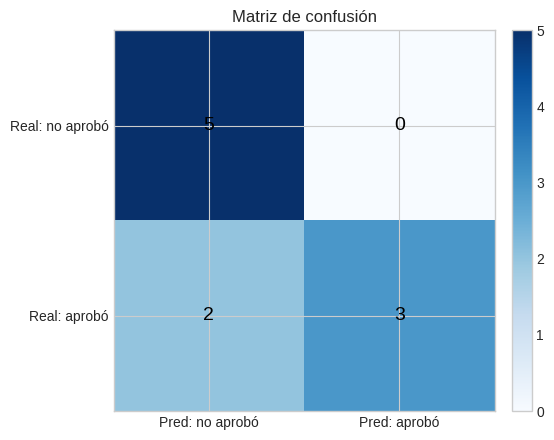

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(matriz, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred: no aprobó', 'Pred: aprobó'])
ax.set_yticklabels(['Real: no aprobó', 'Real: aprobó'])
ax.set_title('Matriz de confusión')

for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        ax.text(j, i, matriz[i, j], ha='center', va='center', color='black', fontsize=14)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


### Interpretación de la matriz de confusión

La matriz de confusión muestra exactamente dónde acertó y dónde falló el modelo:

- **5 verdaderos negativos**: estudiantes que no aprobaron y el modelo predijo correctamente como no aprobados.
- **3 verdaderos positivos**: estudiantes que aprobaron y el modelo predijo correctamente como aprobados.
- **0 falsos positivos**: ningún estudiante que suspendió fue clasificado como aprobado.
- **2 falsos negativos**: dos estudiantes aprobaron, pero el modelo predijo que no aprobarían.

En este caso, el error principal del modelo es ser algo conservador: prefiere no predecir aprobado salvo que la probabilidad sea suficientemente alta.

## 12. Curva ROC y ROC-AUC

La curva ROC evalúa el comportamiento del modelo si cambiamos el umbral de decisión.

El valor **ROC-AUC** resume esa curva en un número entre 0 y 1:

- Cerca de `0.5`: el modelo separa las clases casi como azar.
- Cerca de `1.0`: el modelo separa muy bien las clases.


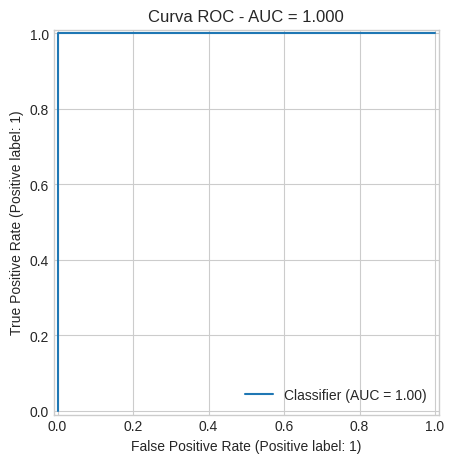

In [11]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title(f'Curva ROC - AUC = {roc_auc:.3f}')
plt.show()


### Interpretación de la curva ROC

La curva ROC analiza el comportamiento del modelo al cambiar el umbral de decisión. En lugar de usar siempre 0.5, evalúa qué pasaría con distintos cortes.

El ROC-AUC de este ejercicio es alto porque el modelo asignó probabilidades mayores a los estudiantes que realmente aprobaron y probabilidades menores a quienes no aprobaron.

Aun así, como solo hay **10 casos de prueba**, no conviene sacar una conclusión demasiado fuerte. En proyectos reales se necesitarían más datos para validar que el rendimiento se mantiene.

## 13. Visualización de la curva sigmoide y frontera de decisión

La regresión logística produce una curva en forma de S llamada **sigmoide**.

Esa curva representa la probabilidad de aprobar según las horas estudiadas. La frontera de decisión aparece cuando la probabilidad llega a `0.5`.


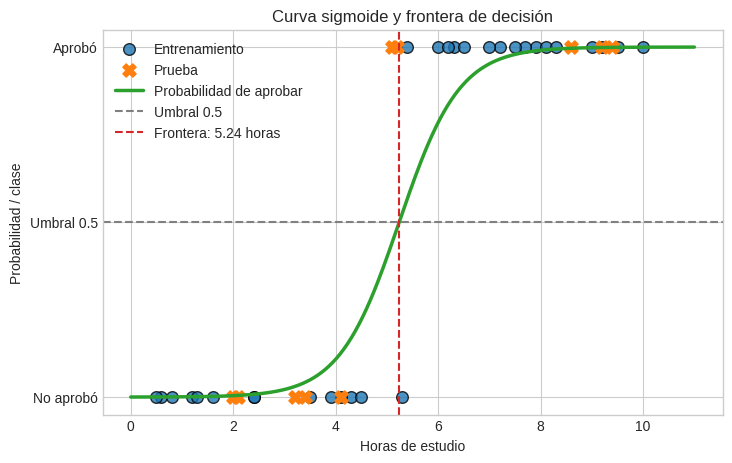

Frontera de decisión aproximada: 5.24 horas de estudio.


In [12]:
horas_grid = pd.DataFrame({'horas_estudio': np.linspace(0, 11, 300)})
probabilidades_grid = modelo.predict_proba(horas_grid)[:, 1]

# Calculamos la hora aproximada en la que la probabilidad llega a 0.5.
frontera_decision = -modelo.intercept_[0] / modelo.coef_[0][0]

plt.scatter(X_train['horas_estudio'], y_train, color='#1f77b4', label='Entrenamiento', s=70, alpha=0.8, edgecolor='black')
plt.scatter(X_test['horas_estudio'], y_test, color='#ff7f0e', label='Prueba', s=90, marker='X')
plt.plot(horas_grid['horas_estudio'], probabilidades_grid, color='#2ca02c', linewidth=2.5, label='Probabilidad de aprobar')
plt.axhline(0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.axvline(frontera_decision, color='#d62728', linestyle='--', label=f'Frontera: {frontera_decision:.2f} horas')
plt.yticks([0, 0.5, 1], ['No aprobó', 'Umbral 0.5', 'Aprobó'])
plt.xlabel('Horas de estudio')
plt.ylabel('Probabilidad / clase')
plt.title('Curva sigmoide y frontera de decisión')
plt.legend()
plt.show()

print(f'Frontera de decisión aproximada: {frontera_decision:.2f} horas de estudio.')


### Interpretación de la curva sigmoide y la frontera de decisión

La curva sigmoide muestra cómo aumenta la probabilidad de aprobar a medida que aumentan las horas de estudio. Al principio la probabilidad es baja, luego sube rápidamente en la zona intermedia y finalmente se acerca a 1.

La frontera de decisión queda aproximadamente en **5.24 horas**. Eso significa que, con el umbral 0.5, el modelo tiende a predecir:

- Menos de 5.24 horas: **no aprobaría**.
- Más de 5.24 horas: **aprobaría**.

Esta frontera no debe interpretarse como una regla absoluta. En la realidad, un estudiante puede aprobar con menos horas o suspender con más horas, porque influyen otros factores que aquí no estamos usando: asistencia, conocimientos previos, dificultad del examen, descanso, práctica, etc.

## 14. Ejemplos de predicción con nuevos estudiantes

Probamos el modelo con dos casos nuevos:

- Un estudiante que estudió pocas horas.
- Un estudiante que estudió muchas horas.

Esto nos ayuda a ver cómo se usaría el modelo en una situación nueva.


In [13]:
nuevos_estudiantes = pd.DataFrame({
    'horas_estudio': [2, 9]
})

nuevas_probabilidades = modelo.predict_proba(nuevos_estudiantes)[:, 1]
nuevas_predicciones = modelo.predict(nuevos_estudiantes)

predicciones_nuevas = nuevos_estudiantes.copy()
predicciones_nuevas['probabilidad_aprobar'] = nuevas_probabilidades
predicciones_nuevas['prediccion'] = nuevas_predicciones
predicciones_nuevas['interpretacion'] = predicciones_nuevas['prediccion'].map({0: 'No aprobaría', 1: 'Aprobaría'})

print(predicciones_nuevas.to_string(index=False, formatters={'probabilidad_aprobar': '{:.3f}'.format}))


 horas_estudio probabilidad_aprobar  prediccion interpretacion
             2                0.004           0   No aprobaría
             9                0.998           1      Aprobaría


### Interpretación de los nuevos casos

El estudiante que estudió **2 horas** obtiene una probabilidad muy baja de aprobar, por eso el modelo predice que no aprobaría.

El estudiante que estudió **9 horas** obtiene una probabilidad muy alta de aprobar, por eso el modelo predice que aprobaría.

Estos ejemplos muestran cómo se podría usar el modelo con datos nuevos. De todos modos, como el modelo solo usa una variable, sus predicciones son muy simples y deberían tomarse como una demostración educativa, no como una evaluación académica real.

## 15. Conclusión final

En este ejercicio construimos un flujo básico de clasificación supervisada con **Regresión Logística**:

1. Creamos un dataset simple y reproducible.
2. Exploramos la relación entre horas de estudio y aprobación.
3. Separamos las variables en `X` e `y`.
4. Dividimos los datos en entrenamiento y prueba.
5. Entrenamos un modelo con `LogisticRegression`.
6. Evaluamos el modelo con métricas de clasificación.
7. Visualizamos la matriz de confusión, la curva ROC y la curva sigmoide.
8. Usamos el modelo para predecir nuevos casos.

La idea principal es que la regresión logística no predice una nota exacta, sino una **probabilidad de pertenecer a una clase**. En este caso, estima la probabilidad de que un estudiante apruebe según sus horas de estudio.

El modelo funcionó razonablemente bien para un ejemplo educativo: acertó el 80% de los casos de prueba. Sin embargo, también cometió errores cerca de la frontera de decisión. Esto muestra una idea importante en clasificación: los casos cercanos al umbral suelen ser los más difíciles.

Este ejemplo es pequeño y usa una sola variable. En un caso real, sería recomendable incluir más información, como asistencia, entregas, participación, notas previas o dificultad del examen. Aun así, el flujo general de trabajo sería similar: preparar los datos, entrenar el modelo, evaluar métricas e interpretar los resultados.